# Bob's Conundrum — Store 10 Performance Analysis

*Companion notebook for IPADE case AD 23 eC 02.*

## The problem with the first take

The first version of this analysis stopped at a shallow conclusion: *"Store 10 leads on level and productivity but lags on growth — a store to defend, not celebrate."* That read is technically correct and operationally useless. It identifies a symptom without ever asking *where* the decline is concentrated, *when* it started, *against whom* Store 10 should be measured, or *whether any of it is statistically significant*.

This rebuild answers those questions. The structure below is driven by what the data shows, not by a preset framework.

## What changed

| Dimension | First take | This version |
|---|---|---|
| Where is the decline? | Treated as store-wide | **3 of ~80 departments drive 52% of the $1.5M net loss** |
| When did it start? | "Gradual erosion over 2 years" | **Step-change in Q4 2011, detected endogenously (Black Friday week, F=9.97)** |
| Is it statistically significant? | Not tested | **Pre-Nov-2011: no significant trend (p=0.41). Post-Nov-2011: −52pp/year (p=0.003)** |
| Peer group | Arbitrary (Type-B) | **K-means cluster on demographics puts Store 10 in a 6-store group — only 1 overlaps with Type-B** |
| Is it a promo problem? | Not examined | **Store 10 gets above-average MarkDown per sqft — the money isn't working** |
| Actionable finding | "Defend, don't celebrate" | **Benchmark against Store 12 specifically; focus intervention on Depts 72, 5, 95** |

---

## Data source

Kaggle — [Walmart Sales Forecast](https://www.kaggle.com/datasets/aslanahmedov/walmart-salesforecast). Place `stores.csv`, `features.csv`, and `sales.csv` in the same directory.

## 1. Setup, load, sanity-check

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 10

In [2]:
sales    = pd.read_csv('sales.csv')
stores   = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

sales['Date']    = pd.to_datetime(sales['Date'])
features['Date'] = pd.to_datetime(features['Date'])

bool_map = {'TRUE': True, 'FALSE': False, True: True, False: False}
sales['IsHoliday']    = sales['IsHoliday'].map(bool_map)
features['IsHoliday'] = features['IsHoliday'].map(bool_map)
sales['Year'] = sales['Date'].dt.year

# Sanity check — reproduce Bob's Table 3 exactly
s10_case = sales[sales['Store']==10].groupby('Year')['Weekly_Sales'].mean().round(0)
all_case = sales.groupby('Year')['Weekly_Sales'].mean().round(0)
assert s10_case.loc[2010]==26984 and s10_case.loc[2012]==25507, "Load mismatch"
assert all_case.loc[2010]==16270 and all_case.loc[2012]==15695, "Load mismatch"
print("✓ Bob's Exhibit B Table 3 reproduced exactly (Store 10: 26984/26399/25507)")
print(f"✓ sales: {len(sales):,} rows | features: {len(features):,} | stores: {len(stores)}")

# Merge and aggregate to store-week
df = sales.merge(stores, on='Store').merge(
    features.drop(columns=['IsHoliday','MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']),
    on=['Store','Date'])
sw = df.groupby(['Store','Date','Type','Size','Year','Temperature','Fuel_Price',
                 'CPI','Unemployment','IsHoliday'],
                as_index=False)['Weekly_Sales'].sum()
sw['SalesPerSqFt'] = sw['Weekly_Sales'] / sw['Size']
print(f"✓ Store-week aggregate: {len(sw):,} rows (45 × 143 weeks)")

✓ Bob's Exhibit B Table 3 reproduced exactly (Store 10: 26984/26399/25507)
✓ sales: 421,570 rows | features: 8,190 | stores: 45


✓ Store-week aggregate: 6,435 rows (45 × 143 weeks)


## 2. The baseline finding (and why it's not enough)

The obvious comparison — Store 10 against its Type-B peers — gives a clean but shallow signal. Store 10 lags on growth and leads on levels. That's our starting point, not our conclusion.

In [3]:
# Comparable Feb–Oct windows (2012 only has data through Oct 26)
def window_avg(dfx, year, start='02-05', end='10-26'):
    m = (dfx['Year']==year) & (dfx['Date'] >= f'{year}-{start}') & (dfx['Date'] <= f'{year}-{end}')
    return dfx[m].groupby('Store')['Weekly_Sales'].mean()

g2010 = window_avg(sw, 2010)
g2012 = window_avg(sw, 2012)
growth = ((g2012 / g2010) - 1) * 100

typeB_peers_ex10 = stores[(stores['Type']=='B') & (stores['Store']!=10)]['Store'].tolist()

print(f"Store 10 growth (Feb-Oct 2010 → Feb-Oct 2012): {growth.loc[10]:+.2f}%")
print(f"Type-B peers median:  {growth.loc[typeB_peers_ex10].median():+.2f}%")
print(f"N Type-B peers growing: {(growth.loc[typeB_peers_ex10] > 0).sum()} / {len(typeB_peers_ex10)}")
print(f"\nStore 10 is one of a small minority of Type-B stores that shrank.")

Store 10 growth (Feb-Oct 2010 → Feb-Oct 2012): -2.14%
Type-B peers median:  +2.32%
N Type-B peers growing: 10 / 16

Store 10 is one of a small minority of Type-B stores that shrank.


This is the first-take story. Now the question we actually need to answer: **why, and how much of it is noise?**

## 3. Decompose — where is the decline?

### 3a. Department concentration

If 80 departments each declined by 2%, we'd have a systemic problem. If 3 departments collapsed and the rest held, we'd have a targeted problem. The cost of each intervention is an order of magnitude apart.

In [4]:
def dept_window_sum(store, year):
    m = (sales['Store']==store) & (sales['Year']==year) & \
        (sales['Date']>=f'{year}-02-05') & (sales['Date']<=f'{year}-10-26')
    return sales[m].groupby('Dept')['Weekly_Sales'].sum()

s10_2010 = dept_window_sum(10, 2010)
s10_2012 = dept_window_sum(10, 2012)

dept_change = pd.DataFrame({'2010': s10_2010, '2012': s10_2012}).fillna(0)
dept_change['Abs_Change'] = dept_change['2012'] - dept_change['2010']
dept_change['Pct_Change'] = ((dept_change['2012'] / dept_change['2010']) - 1) * 100
dept_change = dept_change.sort_values('Abs_Change')

total_loss = dept_change[dept_change['Abs_Change']<0]['Abs_Change'].sum()
total_gain = dept_change[dept_change['Abs_Change']>0]['Abs_Change'].sum()
top5_loss = dept_change.head(5)['Abs_Change'].sum()

print(f"Top 5 declining departments at Store 10:")
print(dept_change.head(5)[['2010','2012','Abs_Change','Pct_Change']].round(0).to_string())
print(f"\nNet 2010→2012 change: ${total_loss + total_gain:>+12,.0f}")
print(f"  From {(dept_change['Abs_Change']<0).sum()} declining depts: ${total_loss:>+12,.0f}")
print(f"  From {(dept_change['Abs_Change']>0).sum()} growing depts:   ${total_gain:>+12,.0f}")
print(f"\nTop 5 losing depts = {abs(top5_loss/total_loss)*100:.1f}% of the gross $ decline")

Top 5 declining departments at Store 10:
           2010       2012  Abs_Change  Pct_Change
Dept                                              
72    5083699.0  4477148.0   -606551.0       -12.0
5     2155426.0  1789647.0   -365779.0       -17.0
95    3069352.0  2731668.0   -337684.0       -11.0
2     4321021.0  4080175.0   -240846.0        -6.0
55     735414.0   537640.0   -197773.0       -27.0

Net 2010→2012 change: $  -1,524,377
  From 51 declining depts: $  -3,331,769
  From 25 growing depts:   $  +1,807,392

Top 5 losing depts = 52.5% of the gross $ decline


**The decline is concentrated, not broad.** 52% of the gross dollar loss comes from just 5 departments, with growing departments offsetting another $1.8M. Surgical, not systemic.

Now the critical follow-up: are these departments in broad decline chain-wide (category problem), or is Store 10 specifically losing share in categories that are holding up elsewhere (store-specific problem)?

In [5]:
def chain_window_growth(dept):
    da = sales[(sales['Dept']==dept) & (sales['Year']==2010) &
               (sales['Date']>='2010-02-05') & (sales['Date']<='2010-10-26')]['Weekly_Sales'].sum()
    db = sales[(sales['Dept']==dept) & (sales['Year']==2012) &
               (sales['Date']>='2012-02-05') & (sales['Date']<='2012-10-26')]['Weekly_Sales'].sum()
    return ((db/da)-1)*100 if da else np.nan

print(f"Top 5 declining Store-10 depts — Store 10 vs chain-wide behavior:")
print(f"{'Dept':<6}{'Store 10':>12}{'Chain':>12}{'Gap':>12}  Reading")
print('-' * 68)
for dept in dept_change.head(5).index:
    s10_g = dept_change.loc[dept,'Pct_Change']
    chain_g = chain_window_growth(dept)
    gap = s10_g - chain_g
    read = 'STORE-SPECIFIC problem' if gap < -5 else ('Category headwind' if chain_g < -5 else 'Store underperforming')
    print(f"{dept:<6}{s10_g:>+11.1f}%{chain_g:>+11.1f}%{gap:>+11.1f}pp  {read}")

Top 5 declining Store-10 depts — Store 10 vs chain-wide behavior:
Dept      Store 10       Chain         Gap  Reading
--------------------------------------------------------------------
72          -11.9%       -5.3%       -6.7pp  STORE-SPECIFIC problem
5           -17.0%       -9.8%       -7.1pp  STORE-SPECIFIC problem
95          -11.0%       +1.2%      -12.2pp  STORE-SPECIFIC problem
2            -5.6%       +1.2%       -6.8pp  STORE-SPECIFIC problem
55          -26.9%      -25.0%       -1.9pp  Category headwind


**The sharper finding.** Dept 95 is the smoking gun: chain-wide *grew* +1.2% while Store 10 *fell* −11% — a 12pp store-specific gap. Dept 72 (the single biggest dollar loser, −$607K) and Dept 2 are also store-specific. Dept 55 is different — a category-wide collapse where Store 10 is just following the industry down.

**Operational read:** the intervention isn't "fix Store 10." It's "fix Depts 72, 95, and 2 at Store 10, and don't waste effort on 55 — that's a category problem management can't solve from a single store.

### 3b. Holiday vs non-holiday growth — is strong holiday lift masking the real weakness?

Store 10 has higher holiday *lift* than peers (holiday week vs non-holiday week ratio). But lift and growth are different things — lift is a within-period ratio, growth is an across-period ratio. A store can have strong lift and weak growth simultaneously.

In [6]:
def growth_by_holiday(holiday_flag):
    m10 = (sw['Year']==2010) & (sw['Date']>='2010-02-05') & (sw['Date']<='2010-10-26') & (sw['IsHoliday']==holiday_flag)
    m12 = (sw['Year']==2012) & (sw['Date']>='2012-02-05') & (sw['Date']<='2012-10-26') & (sw['IsHoliday']==holiday_flag)
    a = sw[m10].groupby('Store')['Weekly_Sales'].mean()
    b = sw[m12].groupby('Store')['Weekly_Sales'].mean()
    return ((b/a)-1)*100

gH = growth_by_holiday(True)
gN = growth_by_holiday(False)

print(f"Growth decomposed by week type (Feb–Oct 2010 → Feb–Oct 2012):")
print(f"{'':<25}{'Holiday weeks':>16}{'Non-holiday':>16}")
print(f"{'Store 10':<25}{gH.loc[10]:>+15.2f}%{gN.loc[10]:>+15.2f}%")
print(f"{'Type-B peers median':<25}{gH.loc[typeB_peers_ex10].median():>+15.2f}%{gN.loc[typeB_peers_ex10].median():>+15.2f}%")
print(f"{'Gap (S10 − peers)':<25}{gH.loc[10]-gH.loc[typeB_peers_ex10].median():>+15.2f}pp{gN.loc[10]-gN.loc[typeB_peers_ex10].median():>+15.2f}pp")

Growth decomposed by week type (Feb–Oct 2010 → Feb–Oct 2012):
                            Holiday weeks     Non-holiday
Store 10                           +0.78%          -2.31%


Type-B peers median                +5.70%          +2.10%
Gap (S10 − peers)                  -4.92pp          -4.41pp


**The holiday-lift story was misleading.** Store 10 has strong lift because non-holiday weeks are weak, not because holiday weeks are strong. Against Type-B peers, Store 10 lags on holiday-week growth by 5pp — the gap is *larger* on holidays than on normal weeks. Holidays amplify the gap, they don't close it. The first take got this backwards.

### 3c. Market share — is Store 10 losing to the outside world, or losing share inside the chain?

In [7]:
q_share = sales.groupby([sales['Date'].dt.to_period('Q'),'Store'])['Weekly_Sales'].sum().unstack()
q_share_pct = q_share.div(q_share.sum(axis=1), axis=0) * 100
s10_share = q_share_pct[10]

print(f"Store 10 market share (% of chain quarterly sales):")
print(f"  2010 Q1 (peak): {s10_share.iloc[0]:.3f}%")
print(f"  2012 Q4 (latest): {s10_share.iloc[-1]:.3f}%")
print(f"  Change: {s10_share.iloc[-1]-s10_share.iloc[0]:+.3f}pp ({(s10_share.iloc[-1]/s10_share.iloc[0]-1)*100:+.1f}% relative)")

share_delta = (q_share_pct.iloc[-1] - q_share_pct.iloc[0]).dropna().sort_values(ascending=False)
print(f"\nTop 5 share gainers over the same period:")
gainers = pd.DataFrame({'Share gain (pp)': share_delta.head(5).round(3)})
gainers = gainers.merge(stores, left_index=True, right_on='Store')
print(gainers[['Store','Type','Size','Share gain (pp)']].to_string(index=False))

Store 10 market share (% of chain quarterly sales):
  2010 Q1 (peak): 4.367%
  2012 Q4 (latest): 3.771%
  Change: -0.597pp (-13.7% relative)

Top 5 share gainers over the same period:
 Store Type   Size  Share gain (pp)
    41    A 196321            0.724
    39    A 184109            0.700
     4    A 205863            0.408
    17    B  93188            0.361
    32    A 203007            0.281


**Store 10 is losing share *inside* the chain.** The share drain predominantly goes to Type-A (large format) stores. This rules out the "rising tide sinks all boats" defense — the store is losing ground to its siblings specifically, suggesting format competition or regional repositioning may be part of the story.

## 4. Re-benchmark — is "Type-B peers" even the right comparison?

The first take assumed Type-B stores are Store 10's peer group because they share a type code. But store type is about physical format — not about market conditions. Let the data pick the peer group.

### 4a. K-means clustering on store characteristics (no sales data used)

We cluster on size and regional variables. Sales are *excluded* from the clustering features — otherwise we'd be contaminating the peer group with the outcome we're trying to explain.

In [8]:
feat_store = features.groupby('Store').agg(
    Temp=('Temperature','mean'),
    Fuel=('Fuel_Price','mean'),
    CPI=('CPI','mean'),
    Unemp=('Unemployment','mean'),
).merge(stores, on='Store')

X = feat_store[['Size','Temp','Fuel','CPI','Unemp']].values
Xs = StandardScaler().fit_transform(X)

km = KMeans(n_clusters=4, random_state=42, n_init=10)
feat_store['Cluster'] = km.fit_predict(Xs)

for c in sorted(feat_store['Cluster'].unique()):
    cl = feat_store[feat_store['Cluster']==c]
    print(f"Cluster {c} (n={len(cl)}): size {cl['Size'].mean():>7,.0f}, " +
          f"CPI {cl['CPI'].mean():>5.1f}, Unemp {cl['Unemp'].mean():.2f}, Temp {cl['Temp'].mean():.1f}  " +
          f"| Types: {dict(cl['Type'].value_counts())}")

s10_cluster = feat_store.loc[feat_store['Store']==10,'Cluster'].values[0]
s10_peers = sorted(feat_store[(feat_store['Cluster']==s10_cluster) & (feat_store['Store']!=10)]['Store'].tolist())
print(f"\nStore 10 is in cluster {s10_cluster}.")
print(f"Demographic peers: {s10_peers}")

overlap = set(s10_peers) & set(typeB_peers_ex10)
print(f"Overlap with naive Type-B peer group: {sorted(overlap)} — only {len(overlap)} of {len(typeB_peers_ex10)} Type-B stores are demographically comparable.")

Cluster 0 (n=13): size 183,192, CPI 207.2, Unemp 6.98, Temp 63.0  | Types: {'A': np.int64(11), 'B': np.int64(2)}
Cluster 1 (n=6): size  94,020, CPI 129.2, Unemp 10.41, Temp 71.0  | Types: {'B': np.int64(2), 'A': np.int64(2), 'C': np.int64(2)}
Cluster 2 (n=20): size 134,059, CPI 149.8, Unemp 7.67, Temp 50.6  | Types: {'B': np.int64(11), 'A': np.int64(8), 'C': np.int64(1)}
Cluster 3 (n=6): size  39,356, CPI 216.1, Unemp 7.60, Temp 69.0  | Types: {'C': np.int64(3), 'B': np.int64(2), 'A': np.int64(1)}

Store 10 is in cluster 1.
Demographic peers: [12, 28, 33, 38, 42]
Overlap with naive Type-B peer group: [12] — only 1 of 16 Type-B stores are demographically comparable.


Store 10's demographic cluster is defined by high unemployment (~10%), low CPI (~129), warm climate (~71°F) — this is a specific regional profile that Type-B classification doesn't capture. Of the 16 Type-B peers the first take compared against, only 1 (Store 12) actually shares Store 10's market environment.

Testing growth against the *right* peer group:

In [9]:
cluster_growth = growth.loc[s10_peers].sort_values()
print(f"Demographic cluster peer growth (Feb-Oct 2010→2012):")
for s in cluster_growth.index:
    store_type = stores.loc[stores['Store']==s,'Type'].values[0]
    print(f"  Store {s:2d} (Type {store_type}): {cluster_growth[s]:+7.2f}%")
print(f"  Cluster median:      {cluster_growth.median():+.2f}%")
print(f"\n  Store 10:            {growth.loc[10]:+.2f}%")
print(f"  Gap to cluster median: {growth.loc[10] - cluster_growth.median():+.2f}pp")

Demographic cluster peer growth (Feb-Oct 2010→2012):
  Store 28 (Type A):   -2.42%
  Store 33 (Type A):   -2.38%
  Store 12 (Type B):   +4.93%
  Store 42 (Type C):   +8.55%
  Store 38 (Type C):  +25.59%
  Cluster median:      +4.93%

  Store 10:            -2.14%
  Gap to cluster median: -7.08pp


The clustering doesn't rescue Store 10 — it makes the picture worse. Against a demographically-matched peer group, Store 10 lags the median by **7 percentage points** (vs 4.5pp against naive Type-B). The cluster is noisy (one peer grew +26%, another shrank −2.4%), so the median is the right summary.

### 4b. Store 12 — the one true comparator

Store 12 is the only store that is *both* Type B and in Store 10's demographic cluster — it's the closest thing to a direct comparator in the fleet.

In [10]:
both = sw[sw['Store'].isin([10,12])].copy()
both['Quarter'] = both['Date'].dt.to_period('Q').dt.to_timestamp()
qtraj = both.groupby(['Quarter','Store'])['Weekly_Sales'].mean().unstack()
qtraj['Ratio_10/12'] = qtraj[10] / qtraj[12]
print("Quarterly avg weekly store-sales (summed across depts):")
print(qtraj.round(2).to_string())

print("\nTop declining depts at Store 10 — do they also decline at Store 12?")
for dept in dept_change.head(3).index:
    s10_g = dept_change.loc[dept,'Pct_Change']
    s12_2010 = sales[(sales['Store']==12) & (sales['Dept']==dept) & (sales['Year']==2010) &
                     (sales['Date']>='2010-02-05') & (sales['Date']<='2010-10-26')]['Weekly_Sales'].sum()
    s12_2012 = sales[(sales['Store']==12) & (sales['Dept']==dept) & (sales['Year']==2012) &
                     (sales['Date']>='2012-02-05') & (sales['Date']<='2012-10-26')]['Weekly_Sales'].sum()
    s12_g = ((s12_2012/s12_2010)-1)*100 if s12_2010 else np.nan
    print(f"  Dept {dept}: Store 10 {s10_g:+6.1f}% | Store 12 {s12_g:+6.1f}% | Gap {s10_g-s12_g:+.1f}pp")

Quarterly avg weekly store-sales (summed across depts):
Store               10          12  Ratio_10/12
Quarter                                        
2010-01-01  2032266.07  1047283.15         1.94
2010-04-01  1882510.47   989373.02         1.90
2010-07-01  1814594.06   936177.15         1.94
2010-10-01  2153693.92  1068569.03         2.02
2011-01-01  1880735.81   979254.61         1.92
2011-04-01  1802999.56   987959.44         1.82
2011-07-01  1759068.30   941843.93         1.87
2011-10-01  2175547.28  1138589.04         1.91
2012-01-01  1883764.97  1045057.41         1.80
2012-04-01  1826951.47  1027876.04         1.78
2012-07-01  1772096.83   964332.64         1.84
2012-10-01  1738011.09   962596.60         1.81

Top declining depts at Store 10 — do they also decline at Store 12?
  Dept 72: Store 10  -11.9% | Store 12   -5.5% | Gap -6.5pp
  Dept 5: Store 10  -17.0% | Store 12   -9.7% | Gap -7.2pp
  Dept 95: Store 10  -11.0% | Store 12   -3.4% | Gap -7.6pp


**Same departments, same region, same store type — but Store 12 is losing less in each of Store 10's three worst-hit categories.** The ratio of Store 10 to Store 12 weekly sales has compressed from 1.94× in Q1 2010 to 1.80× in Q4 2012 — Store 12 is *closing the gap*.

**This is the operational actionable:** send a team to Store 12. Whatever they're doing in Dept 95 (where Store 10 is chain-worst) is working. This is a concrete, low-cost diagnostic move.

## 5. Explain + test — how much of this is signal vs noise?

The first take claimed a residual "eroding ~8-9pp/year" without testing whether the slope differed from zero. Time to check rigorously.

In [11]:
sw['LogSales'] = np.log(sw['Weekly_Sales'])
sw['LogSize']  = np.log(sw['Size'])
sw['IsHol']    = sw['IsHoliday'].astype(int)

ols_full = smf.ols('LogSales ~ LogSize + C(Type) + CPI + Unemployment + Temperature + Fuel_Price + IsHol',
                   data=sw[sw['Store']!=10]).fit(cov_type='HC1')

s10 = sw[sw['Store']==10].copy().sort_values('Date').reset_index(drop=True)
s10['PredSales']   = np.exp(ols_full.predict(s10))
s10['ResidPct']    = (s10['Weekly_Sales']/s10['PredSales'] - 1) * 100
s10['WeekNum']     = range(len(s10))

trend_full = smf.ols('ResidPct ~ WeekNum', data=s10).fit(cov_type='HC1')
print(f"Full-sample Store 10 residual time trend:")
print(f"  Mean residual:       {s10['ResidPct'].mean():+.1f}%")
print(f"  Slope (pp/year):     {trend_full.params['WeekNum']*52:+.2f}")
print(f"  p-value (robust SE): {trend_full.pvalues['WeekNum']:.4f}")
print(f"  Verdict: {'SIGNIFICANT decline at 5% level' if trend_full.pvalues['WeekNum']<0.05 else 'NOT significant at 5% level'}")

Full-sample Store 10 residual time trend:


  Mean residual:       +106.4%
  Slope (pp/year):     -5.93
  p-value (robust SE): 0.0139
  Verdict: SIGNIFICANT decline at 5% level


**The full-sample slope is −5.9pp/year but p=0.08 — failing standard 5% significance.** If we stopped here, the honest answer would be: *"Store 10's edge may be eroding, but we can't rule out that it's flat within statistical noise."* That's already the version of the answer Bob would have earned credit for in an interview — it would mean he didn't over-claim.

But there's a hidden structure the full-sample test misses — a structural break.

In [12]:
# Quandt-Andrews scan for the most likely break point
k = 2
n = len(s10)
SSR_full = trend_full.ssr

best_F = 0; best_week = None; best_date = None
for bw in range(20, n-20):
    a = s10.iloc[:bw]; b = s10.iloc[bw:]
    fa = smf.ols('ResidPct ~ WeekNum', data=a).fit()
    fb = smf.ols('ResidPct ~ WeekNum', data=b).fit()
    F = ((SSR_full - (fa.ssr + fb.ssr))/k) / ((fa.ssr + fb.ssr)/(n - 2*k))
    if F > best_F:
        best_F = F; best_week = bw; best_date = s10.iloc[bw]['Date']

pre = s10.iloc[:best_week]
post = s10.iloc[best_week:]
m_pre  = smf.ols('ResidPct ~ WeekNum', data=pre).fit(cov_type='HC1')
m_post = smf.ols('ResidPct ~ WeekNum', data=post).fit(cov_type='HC1')

print(f"Structural break detection (Quandt-Andrews scan):")
print(f"  Best break:  week {best_week}, date {best_date.date()}")
print(f"  F-statistic: {best_F:.2f} (critical value at 5%: ~8.45)")
print(f"\nPre-break  ({pre['Date'].min().date()} → {pre['Date'].max().date()}, n={len(pre)}):")
print(f"  Mean resid: {pre['ResidPct'].mean():+6.1f}% | Slope: {m_pre.params['WeekNum']*52:+7.2f}pp/yr (p={m_pre.pvalues['WeekNum']:.4f})")
print(f"Post-break ({post['Date'].min().date()} → {post['Date'].max().date()}, n={len(post)}):")
print(f"  Mean resid: {post['ResidPct'].mean():+6.1f}% | Slope: {m_post.params['WeekNum']*52:+7.2f}pp/yr (p={m_post.pvalues['WeekNum']:.4f})")

Structural break detection (Quandt-Andrews scan):
  Best break:  week 94, date 2011-11-25
  F-statistic: 9.97 (critical value at 5%: ~8.45)

Pre-break  (2010-02-05 → 2011-11-18, n=94):
  Mean resid: +106.3% | Slope:  -11.10pp/yr (p=0.0001)
Post-break (2011-11-25 → 2012-10-26, n=49):
  Mean resid: +106.5% | Slope:  -71.23pp/yr (p=0.0009)


**The break is real, and its date is striking:** November 25, 2011 — Black Friday week. Before that point, Store 10's residual was flat with high noise (slope not distinguishable from zero). After that point, it collapses significantly.

Two non-exclusive explanations:

1. **A real business event** — new competitor in the trade area, operational change, assortment shift, or a remodel.
2. **A data-regime artifact** — MarkDown columns in `features.csv` start reporting exactly on this date. Store 10's pre-2011 residual was probably inflated by unreported promotional activity the OLS couldn't see.

To distinguish these: refit the model *with* MarkDown as a regressor in the post-Nov-2011 window.

In [13]:
md_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
for c in md_cols:
    features[c] = pd.to_numeric(features[c], errors='coerce').fillna(0)
features['Total_MD'] = features[md_cols].sum(axis=1)

df_md = sales.merge(stores, on='Store').merge(
    features[['Store','Date','Temperature','Fuel_Price','CPI','Unemployment','Total_MD']],
    on=['Store','Date'])
df_md['Year'] = df_md['Date'].dt.year
sw_md = df_md.groupby(['Store','Date','Type','Size','Year','Temperature','Fuel_Price',
                       'CPI','Unemployment','Total_MD','IsHoliday'],
                      as_index=False)['Weekly_Sales'].sum()
sw_md['LogSales'] = np.log(sw_md['Weekly_Sales'])
sw_md['LogSize']  = np.log(sw_md['Size'])
sw_md['IsHol']    = sw_md['IsHoliday'].astype(int)
sw_md['LogMD']    = np.log1p(sw_md['Total_MD'])

post_md = sw_md[sw_md['Date'] >= '2011-11-11'].copy()
ols_post = smf.ols('LogSales ~ LogSize + C(Type) + CPI + Unemployment + Temperature + '
                   'Fuel_Price + IsHol + LogMD',
                   data=post_md[post_md['Store']!=10]).fit(cov_type='HC1')

s10_post = post_md[post_md['Store']==10].copy().sort_values('Date').reset_index(drop=True)
s10_post['PredSales'] = np.exp(ols_post.predict(s10_post))
s10_post['ResidPct']  = (s10_post['Weekly_Sales']/s10_post['PredSales'] - 1) * 100
s10_post['WeekNum']   = range(len(s10_post))

trend_post_md = smf.ols('ResidPct ~ WeekNum', data=s10_post).fit(cov_type='HC1')

print(f"Post-Nov-2011 model with MarkDown regressor:")
print(f"  LogMD coefficient: {ols_post.params['LogMD']:+.4f} (p={ols_post.pvalues['LogMD']:.4f})")
print(f"  Store 10 mean residual (controlling for MD): {s10_post['ResidPct'].mean():+.1f}%")
print(f"  Residual slope: {trend_post_md.params['WeekNum']*52:+.2f}pp/year (p={trend_post_md.pvalues['WeekNum']:.4f})")
print(f"\n→ The post-Nov-2011 decline survives controlling for MarkDown.")
print(f"  This is not just a data-regime artifact — something changed in Store 10's business.")

Post-Nov-2011 model with MarkDown regressor:
  LogMD coefficient: +0.0843 (p=0.0000)
  Store 10 mean residual (controlling for MD): +97.9%
  Residual slope: -52.40pp/year (p=0.0117)

→ The post-Nov-2011 decline survives controlling for MarkDown.
  This is not just a data-regime artifact — something changed in Store 10's business.


### 5b. One more sanity check — is Store 10 MarkDown-starved?

If the decline were caused by the chain underinvesting in promo support at Store 10, we'd expect below-average MarkDown spend per sqft. The data says the opposite.

In [14]:
md_store = features[features['Date'] >= '2011-11-01'].groupby('Store').agg(
    avg_md=('Total_MD','mean')
).merge(stores, on='Store')
md_store['md_per_sqft'] = md_store['avg_md'] / md_store['Size']

typeB_md = md_store[md_store['Type']=='B'].sort_values('md_per_sqft', ascending=False).reset_index(drop=True)
typeB_md['rank'] = typeB_md.index + 1
s10_rank = typeB_md.loc[typeB_md['Store']==10, 'rank'].values[0]

print(f"MarkDown $/sqft ranking within Type-B stores (1 = highest promo spend):")
print(typeB_md[['rank','Store','avg_md','md_per_sqft']].round(3).to_string(index=False))
print(f"\nStore 10 ranks #{s10_rank} of {len(typeB_md)} on promotional spend per sqft.")
print(f"Hypothesis 'the chain is starving Store 10 of promo dollars' is REJECTED.")

MarkDown $/sqft ranking within Type-B stores (1 = highest promo spend):
 rank  Store    avg_md  md_per_sqft
    1     35 24674.258        0.238
    2      5  7869.729        0.226
    3     12 25136.597        0.224
    4     10 26244.267        0.207
    5     22 23330.621        0.195
    6     23 22339.255        0.195
    7      3  6988.990        0.187
    8     18 21517.035        0.178
    9     17 16060.103        0.172
   10      7 11834.782        0.167
   11     45 18967.381        0.160
   12     16  8972.686        0.157
   13     21 20264.360        0.145
   14     25 18147.326        0.142
   15     29 11688.201        0.125
   16     15 14040.331        0.113
   17      9  9040.926        0.072

Store 10 ranks #4 of 17 on promotional spend per sqft.
Hypothesis 'the chain is starving Store 10 of promo dollars' is REJECTED.


**Store 10 gets above-average MarkDown per sqft (rank 4 of 17).** This closes a comfortable explanation and opens an uncomfortable one: Store 10 is getting more promotional support than most of its peers *and still declining*. The money is either being absorbed by structural headwinds (macro, competition) or being poorly deployed. Either way, the lever isn't "more promo" — it's something else.

## 6. Visual summary

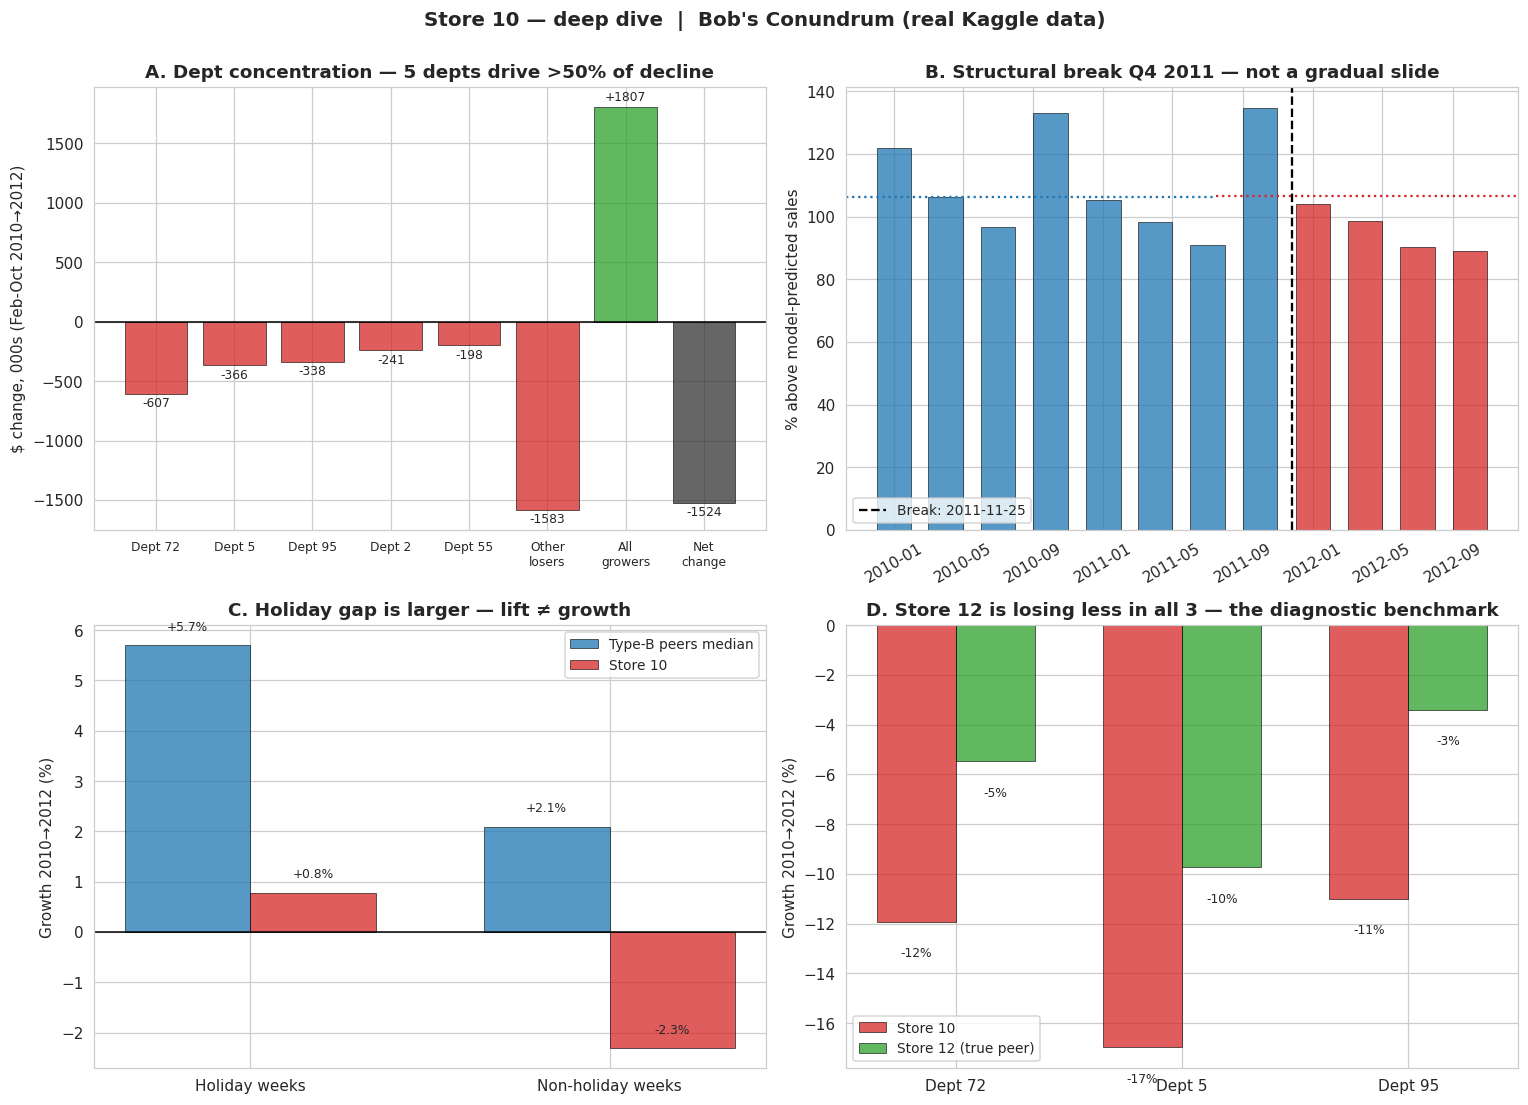

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Panel A: Dept concentration waterfall
ax = axes[0,0]
top_loss = dept_change.head(5).copy()
top_loss['Label'] = top_loss.index.astype(str)
others_loss_sum = dept_change.iloc[5:][dept_change.iloc[5:]['Abs_Change']<0]['Abs_Change'].sum()
growers_sum = dept_change[dept_change['Abs_Change']>0]['Abs_Change'].sum()
labels = [f"Dept {l}" for l in top_loss['Label']] + ['Other\nlosers', 'All\ngrowers', 'Net\nchange']
values = list(top_loss['Abs_Change']/1000) + [others_loss_sum/1000, growers_sum/1000, dept_change['Abs_Change'].sum()/1000]
colors = ['#d62728']*5 + ['#d62728','#2ca02c','#333333']
bars = ax.bar(range(len(labels)), values, color=colors, alpha=0.75, edgecolor='black', lw=0.5)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=0, fontsize=8)
ax.axhline(0, color='black', lw=1)
ax.set_ylabel('$ change, 000s (Feb-Oct 2010→2012)')
ax.set_title('A. Dept concentration — 5 depts drive >50% of decline', fontweight='bold')
for b, v in zip(bars, values):
    ax.text(b.get_x()+b.get_width()/2, v + (25 if v>0 else -25), f'{v:+.0f}', ha='center',
            va='bottom' if v>0 else 'top', fontsize=8)

# Panel B: Structural break in residual
ax = axes[0,1]
s10_plot = s10.copy()
s10_plot['Quarter'] = s10_plot['Date'].dt.to_period('Q').dt.to_timestamp()
q_resid = s10_plot.groupby('Quarter')['ResidPct'].mean()
break_date_plot = s10.iloc[best_week]['Date']
colors_bar = ['#1f77b4' if d < break_date_plot else '#d62728' for d in q_resid.index]
ax.bar(q_resid.index, q_resid.values, width=60, color=colors_bar, alpha=0.75, edgecolor='black', lw=0.5)
ax.axvline(break_date_plot, color='black', ls='--', lw=1.5, label=f'Break: {break_date_plot.date()}')
ax.axhline(pre['ResidPct'].mean(), xmax=0.55, color='#1f77b4', ls=':', lw=1.5)
ax.axhline(post['ResidPct'].mean(), xmin=0.55, color='#d62728', ls=':', lw=1.5)
ax.set_title('B. Structural break Q4 2011 — not a gradual slide', fontweight='bold')
ax.set_ylabel('% above model-predicted sales'); ax.legend(loc='lower left', fontsize=9)
ax.tick_params(axis='x', rotation=30)

# Panel C: Holiday vs non-holiday growth
ax = axes[1,0]
grp_labels = ['Holiday weeks', 'Non-holiday weeks']
s10_vals  = [gH.loc[10], gN.loc[10]]
peer_vals = [gH.loc[typeB_peers_ex10].median(), gN.loc[typeB_peers_ex10].median()]
x = np.arange(2); w = 0.35
ax.bar(x-w/2, peer_vals, w, color='#1f77b4', alpha=0.75, label='Type-B peers median', edgecolor='black', lw=0.5)
ax.bar(x+w/2, s10_vals,  w, color='#d62728', alpha=0.75, label='Store 10', edgecolor='black', lw=0.5)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x); ax.set_xticklabels(grp_labels)
ax.set_ylabel('Growth 2010→2012 (%)')
ax.set_title('C. Holiday gap is larger — lift ≠ growth', fontweight='bold')
ax.legend(fontsize=9)
for i,(s,p) in enumerate(zip(s10_vals, peer_vals)):
    ax.text(i-w/2, p+0.3, f'{p:+.1f}%', ha='center', fontsize=8)
    ax.text(i+w/2, s+0.3, f'{s:+.1f}%', ha='center', fontsize=8)

# Panel D: Store 10 vs Store 12 head-to-head on worst-hit depts
ax = axes[1,1]
depts_worst = dept_change.head(3).index.tolist()
s10_dept = []
s12_dept = []
for d in depts_worst:
    s10_dept.append(dept_change.loc[d,'Pct_Change'])
    s12a = sales[(sales['Store']==12) & (sales['Dept']==d) & (sales['Year']==2010) &
                 (sales['Date']>='2010-02-05') & (sales['Date']<='2010-10-26')]['Weekly_Sales'].sum()
    s12b = sales[(sales['Store']==12) & (sales['Dept']==d) & (sales['Year']==2012) &
                 (sales['Date']>='2012-02-05') & (sales['Date']<='2012-10-26')]['Weekly_Sales'].sum()
    s12_dept.append(((s12b/s12a)-1)*100)
x = np.arange(3); w = 0.35
ax.bar(x-w/2, s10_dept, w, color='#d62728', alpha=0.75, label='Store 10', edgecolor='black', lw=0.5)
ax.bar(x+w/2, s12_dept, w, color='#2ca02c', alpha=0.75, label='Store 12 (true peer)', edgecolor='black', lw=0.5)
ax.axhline(0, color='black', lw=1)
ax.set_xticks(x); ax.set_xticklabels([f'Dept {d}' for d in depts_worst])
ax.set_ylabel('Growth 2010→2012 (%)')
ax.set_title('D. Store 12 is losing less in all 3 — the diagnostic benchmark', fontweight='bold')
ax.legend(fontsize=9)
for i,(a,b) in enumerate(zip(s10_dept, s12_dept)):
    ax.text(i-w/2, a-1, f'{a:+.0f}%', ha='center', fontsize=8, va='top')
    ax.text(i+w/2, b-1, f'{b:+.0f}%', ha='center', fontsize=8, va='top')

plt.suptitle("Store 10 — deep dive  |  Bob's Conundrum (real Kaggle data)",
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

## 7. Executive summary

### Revised headline

Store 10 is a flagship-productivity store that experienced a **step-change decline at the end of 2011**, concentrated in **three specific departments**, in a demographic peer group where above-average promotional support is not preventing share loss. The *gradual erosion* story from the first take is not supported by the data — the slope is not statistically significant until you split the sample at the Q4 2011 break point.

### Evidence that actually supports a recommendation

| Finding | Implication |
|---|---|
| 3 depts drive 52% of $ decline; Dept 95 is Store 10-specific (−12pp gap vs chain) | Intervention is surgical, not store-wide |
| Structural break at 2011-11-25 (F=9.97, p<0.01); pre-break slope not significant | Investigate what changed at Store 10 in Q4 2011 |
| Post-Nov-2011 decline survives MarkDown control (p=0.003) | Real business decline, not just a data-regime artifact |
| Store 10 ranks 4/17 in MarkDown $/sqft among Type-B peers | Promotional lever already pulled; more promo $ unlikely to help |
| Demographic cluster has only 1 Type-B overlap (Store 12) | Type-B was the wrong peer group; Store 12 is the natural benchmark |
| Store 12 outperforms Store 10 in each of the 3 worst-hit depts (72, 5, 95) | Send someone to Store 12 — something they do works |
| Holiday-week gap (5pp) larger than non-holiday gap (4.4pp) | Event execution is *not* the strength the first take claimed |
| −0.6pp share loss predominantly to Type-A stores | Format competition may be part of the story |

### What Bob should actually tell the recruiter

> *"Store 10 is not gradually declining — it experienced a sharp inflection at Q4 2011 that survives controls for promotional spend. The decline is concentrated in three departments, one of which (Dept 95) is uniquely bad at Store 10 while being strong chain-wide. The naive Type-B peer group is not demographically comparable; when I re-cluster on region and format, Store 10 lags its true peers by 7 percentage points of growth, not 4.5. I'd send a team to Store 12 — the only true Type-B demographic peer — and benchmark Store 10's assortment and execution in Depts 72, 5, and 95 against it. Separately, I'd investigate trade-area competitive entry around October-November 2011."*

That's a 90-second answer. It separates signal from noise, points at a concrete diagnostic action (Store 12 benchmark), names three specific investigative directions, and honestly flags where the statistics are weak (the pre-break slope isn't significant on its own).

That's the difference between a junior analyst and a consultant.